# Resonant scattering by a dielectric sphere: fields, geometry and a spectral-method test

**Use case:** illuminate a 2 µm diameter glass sphere with an x-polarized plane
wave, scan visible wavelength, and compare an on-resonance field with a nearby
spectral valley. Show both the exterior interference and the interior standing
field in the x–z meridional plane.

This is deliberately a **sphere**, not a planar Fabry–Pérot replacement.
The converged resonant fields are the independent Lorenz–Mie reference in
`references/mie.py`. A separate calculation below measures the current main
method's single-encounter sphere approximation against that reference.
**Resonant closed-sphere propagation in the main spectral method is pending.**
Displaying Mie fields does not mark that implementation complete.

All lengths are µm; $a=1$ µm, $n_s=1.5$, $n_e=1$, $E_i=\hat{x}e^{ik_ez}$ V/m,
and time dependence is $e^{-i\omega t}$.
[Mie algorithm documentation](https://miepython.readthedocs.io/en/latest/07_algorithm.html)
provides the independent multipole reference.

In [1]:
# Locate this checkout and initialize inline figures.

from pathlib import Path
import sys

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(root))
from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")
import numpy as np
import matplotlib.pyplot as plt
from examples.notebook_tools import style, show, scalar_map, polarization_map, fwhm

style()

## 1. Find a scattering resonance for a fixed physical sphere

We vary wavelength without resizing the sphere. With $x=2\pi n_e a/\lambda_0$,
$$Q_{sca}=\frac{2}{x^2}\sum_{\ell=1}^{\infty}(2\ell+1)
(|a_\ell|^2+|b_\ell|^2).$$
For a lossless sphere, $Q_{ext}=Q_{sca}$. An efficiency peak is not automatically
an isolated high-Q mode; the maps and an internal-field measurement below help
interpret it. The search interval is explicit and the selected peak is refined
numerically rather than chosen by plotting resolution.

In [2]:
# Scan the independent Mie reference for a sphere resonance.

import miepython
from scipy.signal import find_peaks
from scipy.optimize import minimize_scalar
from references.mie import fields as mie_fields

radius = 1.0
sphere_index = 1.5
wavelengths = np.linspace(0.45, 0.65, 1201)
qext, qsca, _, _ = miepython.efficiencies(sphere_index, 2 * radius, wavelengths)
peaks, _ = find_peaks(qsca, prominence=0.12)
assert len(peaks) > 0
j = peaks[np.argmax(qsca[peaks])]
opt = minimize_scalar(
    lambda w: -miepython.efficiencies(sphere_index, 2 * radius, w)[1],
    bounds=(wavelengths[j - 1], wavelengths[j + 1]),
    method="bounded",
    options={"xatol": 1e-12},
)
resonance = float(opt.x)
valleys, _ = find_peaks(-qsca)
near = valleys[abs(valleys - j) > 5]
v = near[np.argmin(abs(near - j))]
off_resonance = float(wavelengths[v])

**Read the result:** The Mie scan identifies the wavelength used in the field maps.

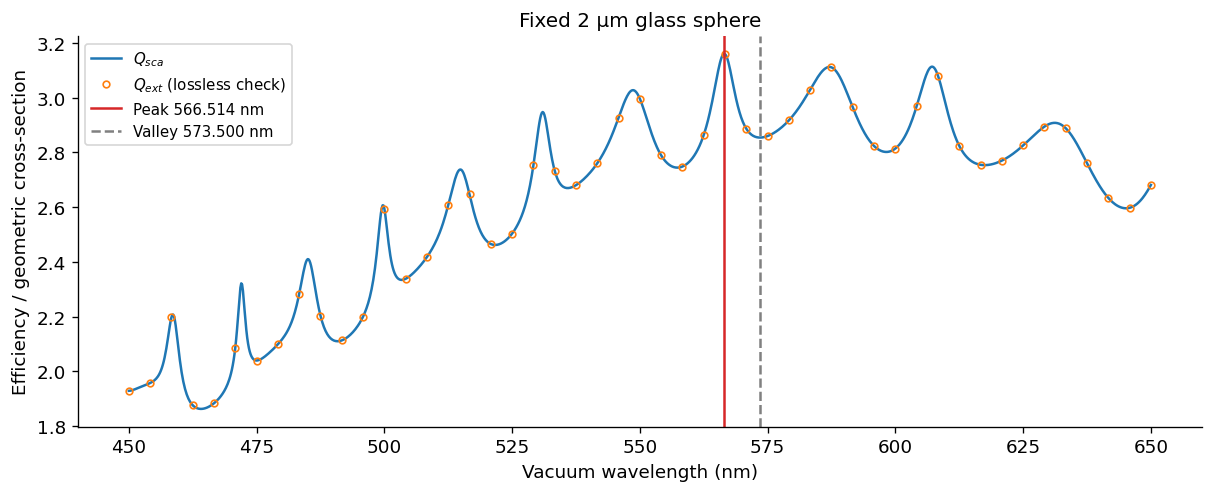

Selected resonance size parameter: 11.090962


In [3]:
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
ax.plot(wavelengths * 1e3, qsca, label=r"$Q_{sca}$")
ax.plot(
    wavelengths[::25] * 1e3,
    qext[::25],
    "o",
    mfc="none",
    ms=4,
    label=r"$Q_{ext}$ (lossless check)",
)
ax.axvline(resonance * 1e3, color="tab:red", label=f"Peak {resonance * 1e3:.3f} nm")
ax.axvline(
    off_resonance * 1e3,
    color="gray",
    ls="--",
    label=f"Valley {off_resonance * 1e3:.3f} nm",
)
ax.set(
    xlabel="Vacuum wavelength (nm)",
    ylabel="Efficiency / geometric cross-section",
    title="Fixed 2 µm glass sphere",
)
ax.legend(fontsize=9)
show(fig, "04_sphere_resonance_scan")

# Lossless Mie extinction and scattering must agree.
assert np.max(abs(qext - qsca)) < 1e-10
print(f"Selected resonance size parameter: {2 * np.pi * radius / resonance:.6f}")

## 2. Plot the resonant and off-resonant total fields with the sphere boundary

The cyan circle is the **actual sphere cross-section**. The incident wave
travels from left to right; the horizontal axis is $z$. The total field outside
is incident plus scattered. Inside, it is the Mie internal field.

All total-norm panels use a shared logarithmic color scale, as do the $E_z$ panels. This
prevents independent peak normalization from hiding resonant enhancement.
The electric and magnetic maps are distinct observables; $Z_0H$ is vecdiff's
magnetic-field convention.

In [4]:
# Evaluate resonant and off-resonant E/H fields in the same meridional window.

from matplotlib.patches import Circle
from matplotlib.colors import LogNorm

x = np.linspace(-1.6, 1.6, 161)
z = np.linspace(-2, 3, 251)
Z, X = np.meshgrid(z, x)
points = np.stack((X, 0 * X, Z), axis=-1)
reference = []
for w in [off_resonance, resonance]:
    reference.append(
        mie_fields(points, radius, wavelength=w, sphere_index=sphere_index)
    )

**Read the result:** Compare resonance and off-resonance on the same field scale.

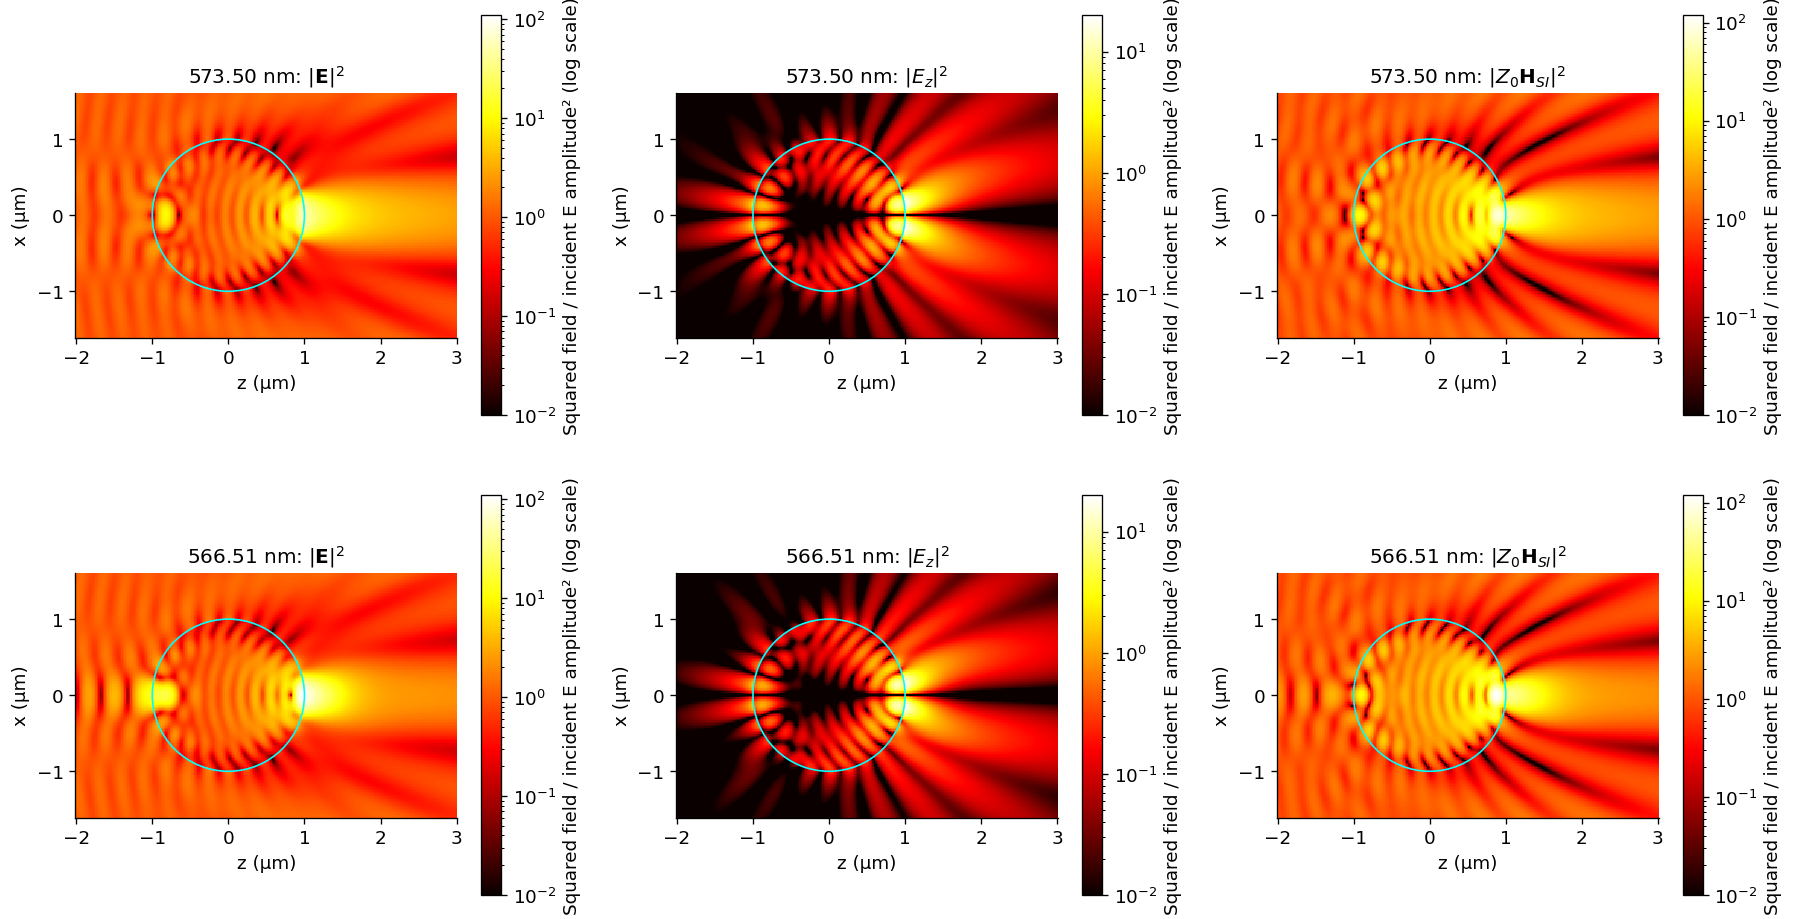

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), layout="constrained")
scales = [
    max(np.sum(abs(pair[0]) ** 2, axis=-1).max() for pair in reference),
    max((abs(pair[0][..., 2]) ** 2).max() for pair in reference),
    max(np.sum(abs(pair[1]) ** 2, axis=-1).max() for pair in reference),
]
for row, ((e, h), w) in enumerate(zip(reference, [off_resonance, resonance])):
    panels = [
        np.sum(abs(e) ** 2, axis=-1),
        abs(e[..., 2]) ** 2,
        np.sum(abs(h) ** 2, axis=-1),
    ]
    for col, (values, title) in enumerate(
        zip(panels, [r"$|\mathbf{E}|^2$", r"$|E_z|^2$", r"$|Z_0\mathbf{H}_{SI}|^2$"])
    ):
        scalar_map(
            fig,
            axes[row, col],
            np.maximum(values, 1e-300),
            z,
            x,
            f"{w * 1e3:.2f} nm: {title}",
            xlabel="z (µm)",
            ylabel="x (µm)",
            norm=LogNorm(0.01, scales[col]),
            label="Squared field / incident E amplitude² (log scale)",
        )
        axes[row, col].add_patch(Circle((0, 0), radius, fill=False, color="cyan", lw=1))
        axes[row, col].set_aspect("equal")
show(fig, "04_sphere_meridional_fields")
# A full-volume quadrature, not a meridional average, measures stored electric norm.

**Read the result:** Check the independent field reference before comparing models.

In [6]:
from numpy.polynomial.legendre import leggauss

u, wu = leggauss(12)
mu, wm = leggauss(16)
rr = radius * (u + 1) / 2
wr = wu * radius / 2
phi = np.arange(32) * 2 * np.pi / 32
R, M, P = np.meshgrid(rr, mu, phi, indexing="ij")
volume_points = np.stack(
    (R * np.sqrt(1 - M * M) * np.cos(P), R * np.sqrt(1 - M * M) * np.sin(P), R * M),
    axis=-1,
)
weights = wr[:, None, None] * wm[None, :, None] * (2 * np.pi / 32) * R**2
for w in [off_resonance, resonance]:
    ev, _ = mie_fields(volume_points, radius, wavelength=w, sphere_index=sphere_index)
    average = np.sum(weights * np.sum(abs(ev) ** 2, axis=-1)) / (
        4 * np.pi * radius**3 / 3
    )
    print(f"{w * 1e3:.3f} nm: volume-mean |E|²/|E0|² = {average:.5f}")

573.500 nm: volume-mean |E|²/|E0|² = 1.21934
566.514 nm: volume-mean |E|²/|E0|² = 2.14632


## 3. Check the reference before using it as a standard

Evaluate fields just outside and inside the sphere, reducing the radial offset.
The four boundary jumps must decrease with that offset. Also increase the
multipole truncation while comparing complex E and H in both media.
This controls the **Mie reference**; it is not validation of the core method.

In [7]:
# Probe two-sided Mie boundary limits and multipole convergence.

from vecdiff import Medium
from vecdiff.observables.electromagnetism import boundary_residuals

mu = np.linspace(-0.96, 0.96, 41)
phi = np.arange(16) * 2 * np.pi / 16
M, P = np.meshgrid(mu, phi, indexing="ij")
normals = np.stack(
    (np.sqrt(1 - M * M) * np.cos(P), np.sqrt(1 - M * M) * np.sin(P), M), axis=-1
)
rows = []
for delta in [1e-4, 1e-6, 1e-8]:
    eo, ho = mie_fields(
        normals * (radius + delta),
        radius,
        wavelength=resonance,
        sphere_index=sphere_index,
    )
    ei, hi = mie_fields(
        normals * (radius - delta),
        radius,
        wavelength=resonance,
        sphere_index=sphere_index,
    )
    rows.append(
        boundary_residuals(
            eo,
            ho,
            ei,
            hi,
            normals,
            Medium(),
            Medium(sphere_index),
            electric_scale=1,
            magnetic_scale=1,
        )
    )

**Read the result:** Track boundary jumps as the two-sided offset shrinks.

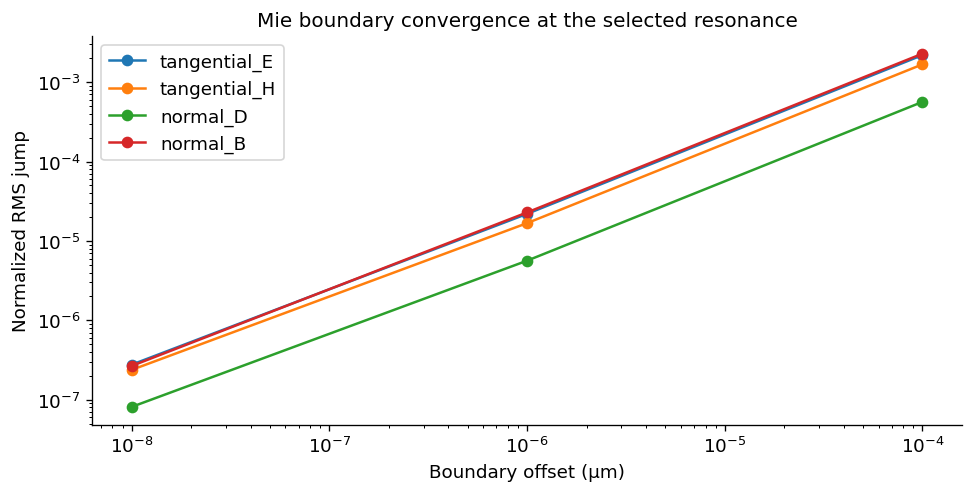

Extra multipoles: relative complex E/H change 1.15e-10
Smallest-offset jumps: {'tangential_E': 2.7651905542124055e-07, 'tangential_H': 2.3776375702125412e-07, 'normal_D': 8.128099449141294e-08, 'normal_B': 2.663999999036877e-07}


In [8]:
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
for key in rows[0]:
    ax.loglog([1e-4, 1e-6, 1e-8], [r[key] for r in rows], "o-", label=key)
ax.set(
    xlabel="Boundary offset (µm)",
    ylabel="Normalized RMS jump",
    title="Mie boundary convergence at the selected resonance",
)
ax.legend()
show(fig, "04_mie_boundary_check")
probe = np.concatenate([normals.reshape(-1, 3)[::17] * radius * s for s in [0.7, 1.3]])
default = mie_fields(probe, radius, wavelength=resonance, sphere_index=sphere_index)
more = mie_fields(
    probe, radius, wavelength=resonance, sphere_index=sphere_index, n_pole=60
)
reference_change = np.linalg.norm(
    np.concatenate(default, axis=-1) - np.concatenate(more, axis=-1)
) / np.linalg.norm(np.concatenate(more, axis=-1))
print(f"Extra multipoles: relative complex E/H change {reference_change:.3g}")
print("Smallest-offset jumps:", rows[-1])

# Control both the boundary offset and multipole truncation.
assert max(rows[-1].values()) < 1e-4 and reference_change < 1e-7

## 4. Put the current spectral approximation beside the Mie field

The diagnostic below constructs local Fresnel transmission on the illuminated
hemisphere and zero transmission in shadow. Interior radiation uses that trace;
exterior scattered radiation uses its difference from the incident trace over
the whole closed sphere. It omits the exit encounter and internal feedback.
This is the existing incomplete model, exposed here so its failure is visible.

A shell of width 0.12 µm is masked because ordinary source quadrature is not a
singular boundary-limit evaluator. Both maps use the same absolute scale and
the error is pointwise complex-vector E error, normalized by incident amplitude.

In [9]:
# Compare the single-encounter spectral model with the full Mie field.

from vecdiff import (
    Sphere,
    SurfaceSampling,
    DielectricInterface,
    plane_wave,
    sample_surface,
    interface_transform,
)
from vecdiff.propagation.surface_radiation import SurfaceRadiation

# ### Closed sphere and quadrature
#
# Join two hemispherical sampling grids into one closed surface.

In [10]:
sphere = Sphere(radius)
halves = [
    sample_surface(sphere, bounds, (0, 2 * np.pi), 32, 64)
    for bounds in [(-1, 0), (0, 1)]
]
samples = SurfaceSampling(
    sphere,
    np.concatenate([s.points for s in halves]),
    np.concatenate([s.normals for s in halves]),
    np.concatenate([s.weights for s in halves]),
)

### Incoming wave and first encounter

Illuminate the closed surface at the resonance wavelength. This model
transforms only the illuminated trace at its first encounter.

In [11]:
wave = plane_wave(wavelength=resonance)
out = interface_transform(
    wave,
    DielectricInterface(sphere, Medium(), Medium(sphere_index), normal_sign=-1),
    samples,
    illuminated_only=True,
)
b = out.boundary

### Scattered boundary currents

Exterior radiation uses the difference between transmitted and incident
traces over the closed sampling surface.

In [12]:
scattered = SurfaceRadiation.from_boundary(
    samples,
    b.transmitted_E - b.incident_E,
    b.transmitted_H - b.incident_H,
    resonance,
    Medium(),
    normal_sign=1,
)

**Next step:** Evaluate both models on the same observation grid.

In [13]:
xx = np.linspace(-1.6, 1.6, 101)
zz = np.linspace(-2, 3, 151)
ZZ, XX = np.meshgrid(zz, xx)
p = np.stack((XX, 0 * XX, ZZ), axis=-1)
distance = np.linalg.norm(p, axis=-1)
inside = distance < radius - 0.12
outside = distance > radius + 0.12
valid = inside | outside
approx = np.full(p.shape, np.nan + 0j)
approx[inside] = out.transmitted.evaluate(p[inside])[0]
approx[outside] = wave.evaluate(p[outside])[0] + scattered.evaluate(p[outside])[0]
truth = mie_fields(p, radius, wavelength=resonance, sphere_index=sphere_index)[0]

**Read the result:** Map where the single-encounter model differs from full Mie feedback.

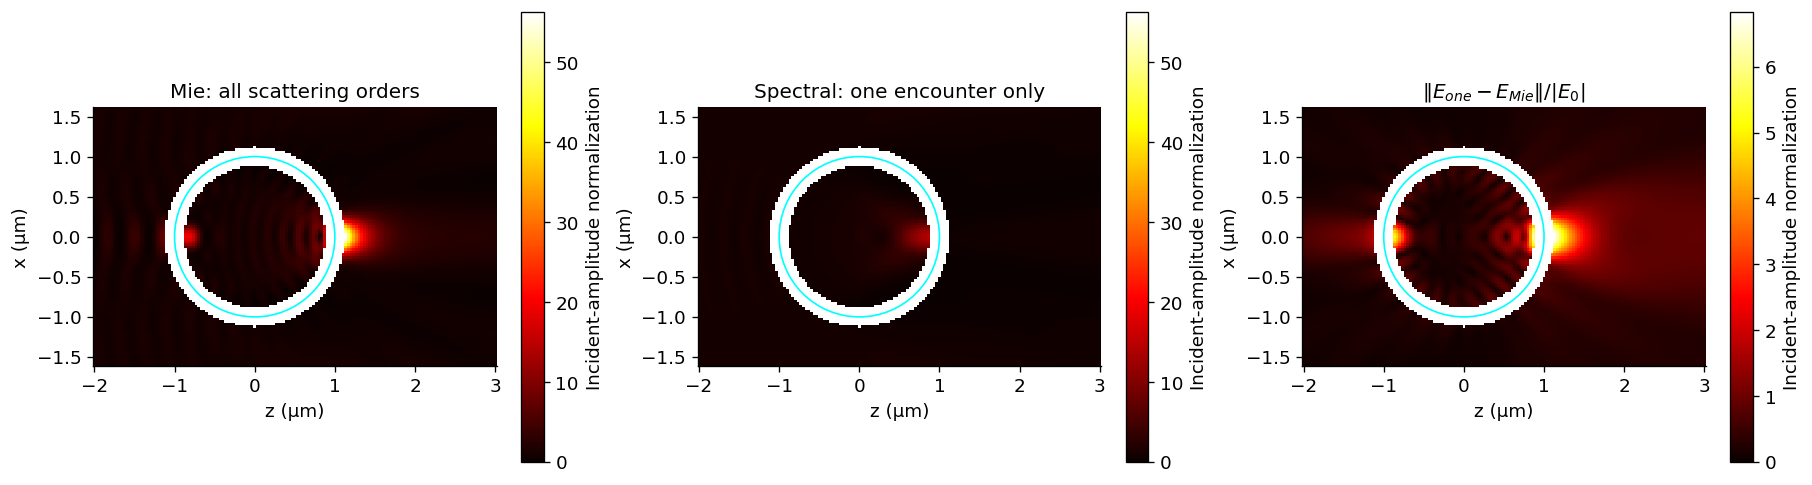

Interior complex E relative error at the selected resonance: 61.80%
Exterior complex E relative error at the selected resonance: 61.65%


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), layout="constrained")
vmax = np.max(np.sum(abs(truth[valid]) ** 2, axis=-1))
for ax, values, title in zip(
    axes,
    [
        np.sum(abs(truth) ** 2, axis=-1),
        np.sum(abs(approx) ** 2, axis=-1),
        np.linalg.norm(approx - truth, axis=-1),
    ],
    [
        "Mie: all scattering orders",
        "Spectral: one encounter only",
        r"$\|E_{one}-E_{Mie}\|/|E_0|$",
    ],
):
    scalar_map(
        fig,
        ax,
        np.where(valid, values, np.nan),
        zz,
        xx,
        title,
        xlabel="z (µm)",
        ylabel="x (µm)",
        vmax=vmax if ax is not axes[2] else None,
        label="Incident-amplitude normalization",
    )
    ax.add_patch(Circle((0, 0), radius, fill=False, color="cyan"))
    ax.set_aspect("equal")
show(fig, "04_spectral_vs_mie")

# Report errors inside and outside the sphere separately.
for name, mask in [("Interior", inside), ("Exterior", outside)]:
    error = np.linalg.norm(approx[mask] - truth[mask]) / np.linalg.norm(truth[mask])
    print(f"{name} complex E relative error at the selected resonance: {error:.2%}")

**Interpretation:** the complete sphere calculation has a resonant spectrum and
an internal/external meridional field. The main method's present sphere trace
is visibly inadequate. Repeated refractions/reflections, closed-surface coupling,
independent boundary residuals and resonance convergence are still required
before it can produce these resonances itself. A lower quadrature error or a
successful planar cavity calculation cannot substitute for those checks.